# Financial Fraud Detection — Exploratory Data Analysis

Dataset: `financial_fraud_detection_dataset.csv` (primary dataset — see README for selection rationale).

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from src.preprocessing import load_raw_data, validate_data, clean_data
from src.feature_engineering import engineer_features

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Dataset Overview

In [2]:
df = load_raw_data()
print('Shape:', df.shape)
df.head()

2026-09-13 15:11:47,343 | INFO     | src.preprocessing | Loading raw dataset from /home/claude/financial-fraud-detection/data/raw/financial_fraud_detection_dataset.csv


2026-09-13 15:11:47,393 | INFO     | src.preprocessing | Loaded 5000 rows, 14 columns


Shape: (5000, 14)


,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
0,T100000,CUST3252,04-10-2023 07:45,37.54,Travel,PayPal,POS,Bengaluru,0,94,417.40,1492,No,0
1,T100001,CUST1630,26-09-2023 08:29,240.81,Utilities,PayPal,Mobile,Bengaluru,0,76,335.47,66,No,0
2,T100002,CUST7852,18-07-2023 15:54,105.34,Entertainment,Debit Card,Mobile,Bengaluru,0,60,432.03,216,No,0
3,T100003,CUST4892,16-10-2023 17:10,73.04,Utilities,NetBanking,Desktop,Kolkata,0,68,488.30,449,No,0
4,T100004,CUST8831,09-09-2023 00:46,13.57,Utilities,Credit Card,Desktop,Bengaluru,0,57,437.03,754,No,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         5000 non-null   str    
 1   Customer_ID            5000 non-null   str    
 2   Transaction_Date       5000 non-null   str    
 3   Transaction_Amount     5000 non-null   float64
 4   Merchant_Category      5000 non-null   str    
 5   Payment_Method         5000 non-null   str    
 6   Device_Type            5000 non-null   str    
 7   Location               5000 non-null   str    
 8   Is_International       5000 non-null   int64  
 9   Previous_Transactions  5000 non-null   int64  
 10  Average_Spend          5000 non-null   float64
 11  Account_Age_Days       5000 non-null   int64  
 12  Suspicious_Keyword     5000 non-null   str    
 13  Fraudulent             5000 non-null   int64  
dtypes: float64(2), int64(4), str(8)
memory usage: 844.6 KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction_ID,5000,5000,T100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,5000,3847,CUST8944,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction_Date,5000,4980,02-03-2023 14:37,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction_Amount,5000.0,NaN,NaN,NaN,79.180664,78.964045,0.0,22.365,55.455,110.2975,653.8
Merchant_Category,5000,8,Food,684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment_Method,5000,5,NetBanking,1037,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Device_Type,5000,3,Desktop,1679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,5000,7,Delhi,758,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Is_International,5000.0,NaN,NaN,NaN,0.0882,0.283614,0.0,0.0,0.0,0.0,1.0
Previous_Transactions,5000.0,NaN,NaN,NaN,99.414,57.022968,1.0,50.0,100.0,148.0,199.0


## 2. Missing Values

In [5]:
missing = df.isnull().sum()
print(missing)
assert missing.sum() == 0, 'Unexpected missing values'
print('No missing values in the raw dataset.')

Transaction_ID           0
Customer_ID              0
Transaction_Date         0
Transaction_Amount       0
Merchant_Category        0
Payment_Method           0
Device_Type              0
Location                 0
Is_International         0
Previous_Transactions    0
Average_Spend            0
Account_Age_Days         0
Suspicious_Keyword       0
Fraudulent               0
dtype: int64
No missing values in the raw dataset.


## 3. Fraud Distribution

In [6]:
fraud_counts = df['Fraudulent'].value_counts()
print(fraud_counts)
print(f"Fraud rate: {df['Fraudulent'].mean()*100:.2f}%")

fig = px.pie(names=['Genuine','Fraud'], values=fraud_counts.values, title='Fraud vs Genuine Transactions')
fig.show()

Fraudulent
0    4518
1     482
Name: count, dtype: int64
Fraud rate: 9.64%


## 4. Transaction Amount Distribution

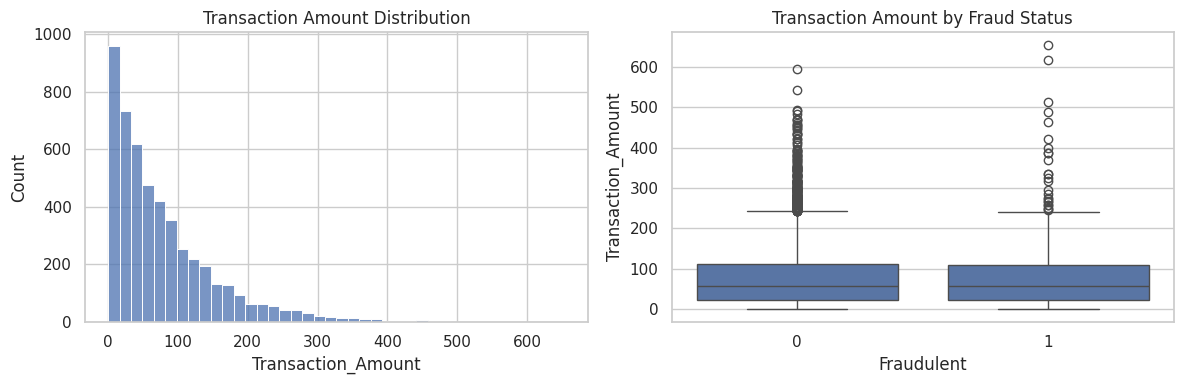

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['Transaction_Amount'], bins=40, ax=ax[0])
ax[0].set_title('Transaction Amount Distribution')
sns.boxplot(x='Fraudulent', y='Transaction_Amount', data=df, ax=ax[1])
ax[1].set_title('Transaction Amount by Fraud Status')
plt.tight_layout()
plt.savefig('../reports/eda_amount_distribution.png', dpi=150)
plt.show()

## 5. Fraud Rate by Merchant Category

In [8]:
cat_fraud = df.groupby('Merchant_Category')['Fraudulent'].mean().sort_values(ascending=False) * 100
cat_fraud

Merchant_Category
Entertainment    11.428571
Food             10.818713
Fashion          10.197368
Health           10.066007
Travel            9.348915
Grocery           9.220986
Utilities         8.417508
Electronics       7.538462
Name: Fraudulent, dtype: float64

## 6. Fraud Rate by Payment Method

In [9]:
pm_fraud = df.groupby('Payment_Method')['Fraudulent'].mean().sort_values(ascending=False) * 100
pm_fraud

Payment_Method
UPI            10.405827
Debit Card     10.218254
Credit Card     9.876543
PayPal          9.589041
NetBanking      8.196721
Name: Fraudulent, dtype: float64

## 7. Fraud Rate by Device Type

In [10]:
dev_fraud = df.groupby('Device_Type')['Fraudulent'].mean().sort_values(ascending=False) * 100
dev_fraud

Device_Type
Desktop    10.244193
POS         9.503885
Mobile      9.162621
Name: Fraudulent, dtype: float64

## 8. Fraud Rate by Location

In [11]:
loc_fraud = df.groupby('Location')['Fraudulent'].mean().sort_values(ascending=False) * 100
loc_fraud

Location
Chennai      10.534351
Mumbai       10.526316
Bengaluru    10.349854
Kolkata      10.238429
Hyderabad     8.827586
Pune          8.587258
Delhi         8.575198
Name: Fraudulent, dtype: float64

## 9. Fraud Rate by International Transaction Flag

In [12]:
intl_fraud = df.groupby('Is_International')['Fraudulent'].mean() * 100
intl_fraud

Is_International
0     6.997148
1    36.961451
Name: Fraudulent, dtype: float64

## 10. Customer Behavior: Previous Transactions & Average Spend

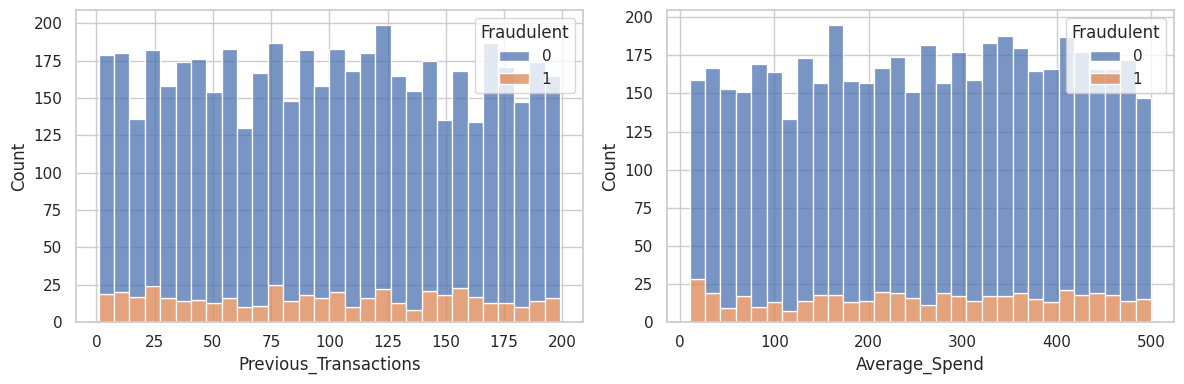

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(data=df, x='Previous_Transactions', hue='Fraudulent', bins=30, ax=ax[0], multiple='stack')
sns.histplot(data=df, x='Average_Spend', hue='Fraudulent', bins=30, ax=ax[1], multiple='stack')
plt.tight_layout()
plt.show()

## 11. Correlation Analysis (numeric columns)

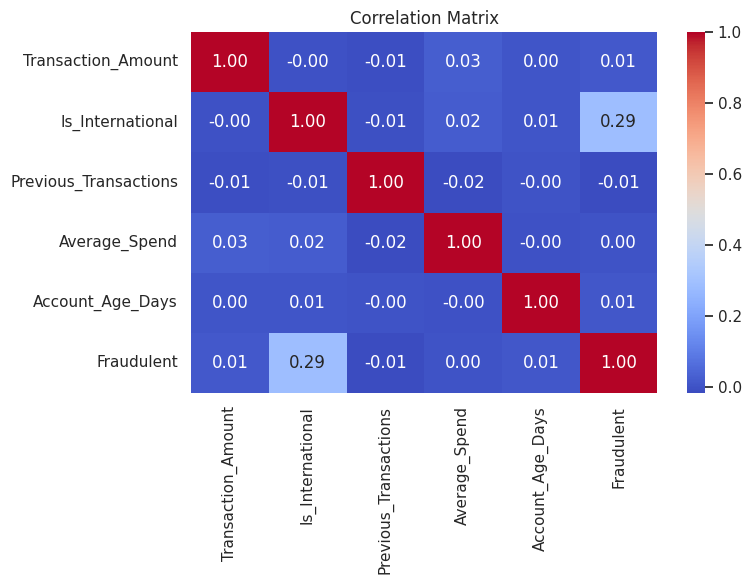

In [14]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/eda_correlation.png', dpi=150)
plt.show()

## 12. Outlier Analysis (Transaction Amount, IQR method)

In [15]:
q1, q3 = df['Transaction_Amount'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = df[(df['Transaction_Amount'] < lower) | (df['Transaction_Amount'] > upper)]
print(f'Outlier bounds: [{lower:.2f}, {upper:.2f}]')
print(f'Number of outlier transactions: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')

Outlier bounds: [-109.53, 242.20]
Number of outlier transactions: 240 (4.80%)


## 13. Time-Based Fraud Analysis

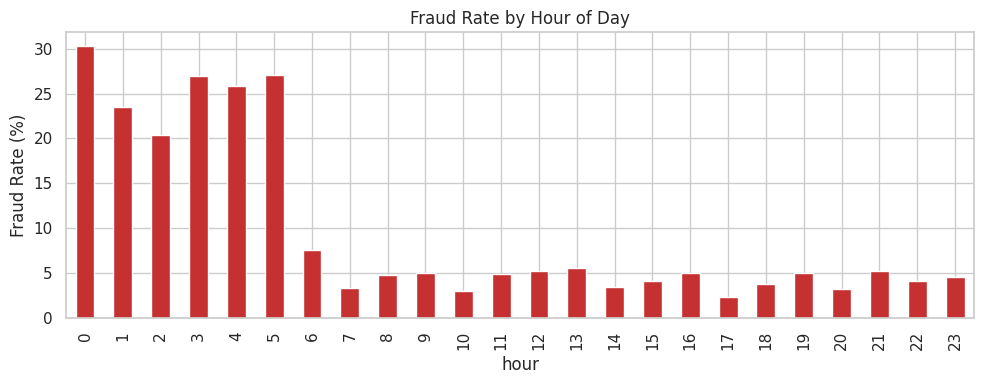

In [16]:
df_time = df.copy()
df_time['Transaction_Date'] = pd.to_datetime(df_time['Transaction_Date'], dayfirst=True, errors='coerce')
df_time['hour'] = df_time['Transaction_Date'].dt.hour
hourly_fraud = df_time.groupby('hour')['Fraudulent'].mean() * 100

plt.figure(figsize=(10,4))
hourly_fraud.plot(kind='bar', color='#c53030')
plt.title('Fraud Rate by Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.savefig('../reports/eda_hourly_fraud.png', dpi=150)
plt.show()

## 14. Data Quality Report (via src.preprocessing.validate_data)

In [17]:
report = validate_data(df)
report.to_dict()

2026-09-13 15:11:49,707 | INFO     | src.preprocessing | Data quality report generated: {'total_rows': 5000, 'total_columns': 14, 'missing_values': {'Transaction_ID': 0, 'Customer_ID': 0, 'Transaction_Date': 0, 'Transaction_Amount': 0, 'Merchant_Category': 0, 'Payment_Method': 0, 'Device_Type': 0, 'Location': 0, 'Is_International': 0, 'Previous_Transactions': 0, 'Average_Spend': 0, 'Account_Age_Days': 0, 'Suspicious_Keyword': 0, 'Fraudulent': 0}, 'duplicate_rows': 0, 'duplicate_transaction_ids': 0, 'negative_amounts': 0, 'zero_or_negative_account_age': 0, 'invalid_timestamps': 0, 'unexpected_categorical_values': {}, 'class_distribution': {0: 4518, 1: 482}, 'class_imbalance_ratio': 9.37, 'potential_leakage_columns': []}


{'total_rows': 5000,
 'total_columns': 14,
 'missing_values': {'Transaction_ID': 0,
  'Customer_ID': 0,
  'Transaction_Date': 0,
  'Transaction_Amount': 0,
  'Merchant_Category': 0,
  'Payment_Method': 0,
  'Device_Type': 0,
  'Location': 0,
  'Is_International': 0,
  'Previous_Transactions': 0,
  'Average_Spend': 0,
  'Account_Age_Days': 0,
  'Suspicious_Keyword': 0,
  'Fraudulent': 0},
 'duplicate_rows': 0,
 'duplicate_transaction_ids': 0,
 'negative_amounts': 0,
 'zero_or_negative_account_age': 0,
 'invalid_timestamps': 0,
 'unexpected_categorical_values': {},
 'class_distribution': {0: 4518, 1: 482},
 'class_imbalance_ratio': 9.37,
 'potential_leakage_columns': []}

## Summary

- The dataset has no missing values and no duplicate rows/transaction IDs.
- Fraud is imbalanced at roughly 9-10% of transactions — accuracy alone is not a reliable metric.
- Certain merchant categories, payment methods, and international transactions show elevated fraud rates (see sections 5-9 for exact values on your run).
- These patterns motivate the behavioral features engineered in `src/feature_engineering.py` (amount deviation from customer average, account age, suspicious keyword flag, etc.).